# FEDERATED UMAP DATA GENERATION

## Loading libraries and importing packages

In [1]:
import os
import math
import datetime
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from sklearn.impute import KNNImputer
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import StratifiedShuffleSplit

import umap

## Function definitions

In [2]:
def mad_centroid(group):
    return np.median(group, axis=0)


def cluster_radius_for_centroid(points_2d, centroid, density_th, percent_th, n_class):
    distances = np.linalg.norm(points_2d - centroid, axis=1)
    rad = 1
    rad_def = rad
    percent = 0.0
    density = float('inf')
    while not (percent >= percent_th and density <= density_th):
        rad_def = rad
        rad += 1
        n_inside = int(np.sum(distances <= rad))
        area = math.pi * rad ** 2
        density = n_inside / area
        percent = n_inside / max(n_class, 1)
        if rad > 200:
            break
    return rad_def

# Load data and simulate the federation

In [3]:
picai = pd.read_csv('marksheet_minimal.csv')
picai = picai.drop(['psad', 'psad_computed'], axis=1)
print('Loaded marksheet:', picai.shape)

K = 3
RANDOM_STATE = 23

def split_into_hospitals(df, k, label_col, seed):
    parts = []
    remainder = df.copy()
    for i in range(k - 1):
        sss = StratifiedShuffleSplit(
            n_splits=1, test_size=1.0 / (k - i), random_state=seed + i
        )
        rest_idx, hosp_idx = next(sss.split(remainder, remainder[label_col]))
        parts.append(remainder.iloc[hosp_idx].reset_index(drop=True))
        remainder = remainder.iloc[rest_idx].reset_index(drop=True)
    parts.append(remainder.reset_index(drop=True))
    return parts

hospitals_raw = split_into_hospitals(picai, K, 'case_csPCa', RANDOM_STATE)
for i, h in enumerate(hospitals_raw):
    print(f'  Hospital {i}: n={len(h):4d}  csPCa+ rate={h["case_csPCa"].mean():.3f}')

Loaded marksheet: (1500, 4)
  Hospital 0: n= 500  csPCa+ rate=0.284
  Hospital 1: n= 500  csPCa+ rate=0.282
  Hospital 2: n= 500  csPCa+ rate=0.284


## Step 1 — Local KNN imputation
Each hospital imputes its own missing values locally. **No data leaves the site.**

In [4]:
hospitals = []
for i, h in enumerate(hospitals_raw):
    imp = KNNImputer(n_neighbors=10)
    arr = imp.fit_transform(h.copy())
    hospitals.append(pd.DataFrame(arr, columns=h.columns))
    n_missing = h.isna().sum().sum()
    print(f'Hospital {i}: imputed {n_missing} missing cells locally')

Hospital 0: imputed 21 missing cells locally
Hospital 1: imputed 16 missing cells locally
Hospital 2: imputed 30 missing cells locally


## Step 2 — Federated standardization

In [5]:
FEATURES = ['patient_age', 'psa', 'prostate_volume']

local_stats = []
for h in hospitals:
    X = h[FEATURES].to_numpy()
    local_stats.append({'n': len(X), 'sum': X.sum(axis=0), 'sum_sq': (X ** 2).sum(axis=0)})

n_total = sum(s['n'] for s in local_stats)
sum_total = np.sum([s['sum'] for s in local_stats], axis=0)
sumsq_total = np.sum([s['sum_sq'] for s in local_stats], axis=0)
global_mean = sum_total / n_total
global_std = np.sqrt(np.maximum(sumsq_total / n_total - global_mean ** 2, 1e-12))
print('Global mean:', np.round(global_mean, 3))
print('Global std :', np.round(global_std, 3))

def federated_standardize(X):
    return (X - global_mean) / global_std

Global mean: [65.595 11.941 65.13 ]
Global std : [ 7.189 14.746 36.164]


## Step 3 — Shared UMAP via anchor hospital

In [6]:
anchor_idx = 0
anchor = hospitals[anchor_idx]
X_anchor = federated_standardize(anchor[FEATURES].to_numpy())
y_anchor = anchor['case_csPCa'].to_numpy()

manifold = umap.UMAP(random_state=RANDOM_STATE).fit(X_anchor, y_anchor)

local_umap, local_labels, local_features = [], [], []
for i, h in enumerate(hospitals):
    Xh = federated_standardize(h[FEATURES].to_numpy())
    yh = h['case_csPCa'].to_numpy()
    local_umap.append(manifold.transform(Xh))
    local_labels.append(yh)
    local_features.append(h[FEATURES].to_numpy())
    print(f'Hospital {i}: projected {len(Xh)} points into shared UMAP')

Hospital 0: projected 500 points into shared UMAP
Hospital 1: projected 500 points into shared UMAP
Hospital 2: projected 500 points into shared UMAP


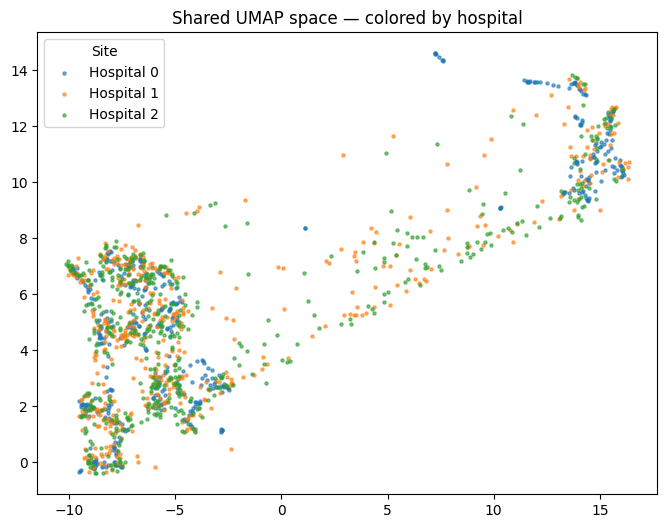

In [7]:
plt.figure(figsize=(8, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']
for i, (proj, y) in enumerate(zip(local_umap, local_labels)):
    plt.scatter(proj[:, 0], proj[:, 1], c=colors[i], s=5, alpha=0.6, label=f'Hospital {i}')
plt.legend(title='Site')
plt.title('Shared UMAP space — colored by hospital')
plt.savefig('B_fed_perhosp_umap.png', dpi=200, bbox_inches='tight')
plt.show()

## Step 4 — Federated centroids and radii

In [8]:
classes = np.unique(np.concatenate(local_labels))
percent_th = 0.9
density_th = 4

# 4a: local centroids -> weighted average
local_centroids = []
for umap_i, y_i in zip(local_umap, local_labels):
    d = {}
    for c in classes:
        m = y_i == c
        if m.sum() > 0:
            d[c] = (mad_centroid(umap_i[m]), int(m.sum()))
    local_centroids.append(d)

federated_centroids = {}
for c in classes:
    ws, tot = np.zeros(2), 0
    for d in local_centroids:
        if c in d:
            cent, n = d[c]
            ws += cent * n
            tot += n
    federated_centroids[c] = ws / tot
    print(f'Class {int(c)}: federated centroid = {np.round(federated_centroids[c], 3)} (n={tot})')

# 4b: local radii -> max
local_radii = []
for umap_i, y_i in zip(local_umap, local_labels):
    rd = {}
    for c in classes:
        m = y_i == c
        if m.sum() == 0:
            continue
        rd[c] = cluster_radius_for_centroid(
            umap_i[m], federated_centroids[c], density_th, percent_th, n_class=int(m.sum())
        )
    local_radii.append(rd)

federated_radii = {}
for c in classes:
    federated_radii[c] = max(rd[c] for rd in local_radii if c in rd)
    print(f'Class {int(c)}: federated radius (max) = {federated_radii[c]}')

Class 0: federated centroid = [-6.606  4.39 ] (n=1075)
Class 1: federated centroid = [2.828 8.161] (n=425)
Class 0: federated radius (max) = 16
Class 1: federated radius (max) = 13


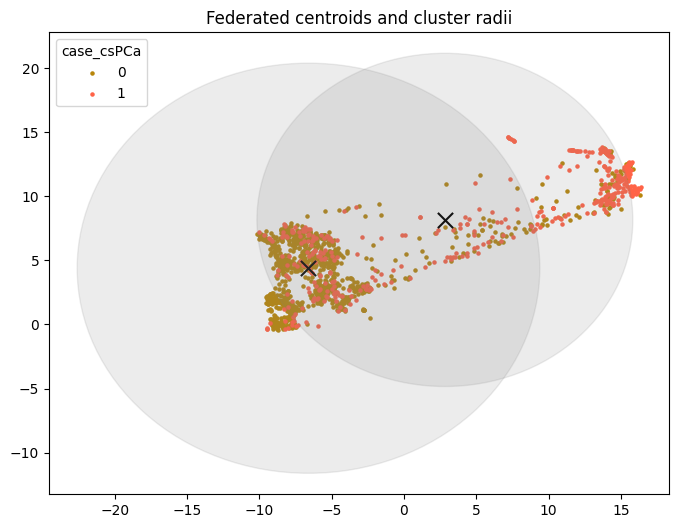

In [9]:
# Visualize federated clusters
plt.figure(figsize=(8, 6))
all_proj = np.concatenate(local_umap)
all_y = np.concatenate(local_labels)
plt.scatter(all_proj[all_y == 0, 0], all_proj[all_y == 0, 1], c='darkgoldenrod', s=5, label='0')
plt.scatter(all_proj[all_y == 1, 0], all_proj[all_y == 1, 1], c='tomato', s=5, label='1')
for c, cent in federated_centroids.items():
    plt.scatter(cent[0], cent[1], c='black', marker='x', s=120)
    plt.gca().add_patch(Circle(cent, federated_radii[c], color='grey', alpha=0.15))
plt.legend(title='case_csPCa')
plt.title('Federated centroids and cluster radii')
plt.savefig('B_fed_ref_umap.png', dpi=200, bbox_inches='tight')
plt.show()

## Step 5 — Federated epsilons

In [10]:
n_neigh = 10
local_eps = []
for umap_i, X_i in zip(local_umap, local_features):
    if len(umap_i) <= n_neigh:
        continue
    nbrs = NearestNeighbors(n_neighbors=n_neigh, algorithm='auto').fit(umap_i)
    _, idxs = nbrs.kneighbors(umap_i)
    eps_local = []
    for idx in range(X_i.shape[1]):
        mean_neigh = np.mean(X_i[idxs, idx], axis=1)
        feat_dis = np.abs(mean_neigh - X_i[:, idx])
        eps_local.append(np.mean(feat_dis))
    local_eps.append((np.array(eps_local), len(umap_i)))

tot = sum(n for _, n in local_eps)
eps_v = np.zeros(len(FEATURES))
for arr, n in local_eps:
    eps_v += arr * n
eps_v = np.maximum(np.round(eps_v / tot).astype(int), 1)
print('Federated epsilons (age, psa, pvol):', eps_v.tolist())

Federated epsilons (age, psa, pvol): [1, 4, 7]


## Step 6 — Local synthetic generation under the shared rules

In [11]:
sel_reliability = 1
step_v = [1, 0.5, 1]

min_values = np.min(X_anchor * global_std + global_mean, axis=0)
max_values = np.max(X_anchor * global_std + global_mean, axis=0)
minmax_v = [
    [min_values[0], max_values[0]],
    [0, 100],
    [min_values[2], max_values[2]],
]

def local_generation_at_hospital(hosp_features_df, manifold, norm_fn,
                                 federated_centroids, federated_radii,
                                 eps_v, minmax_v, step_v,
                                 sel_reliability, n_neigh):
    X_local = hosp_features_df.to_numpy()
    umap_local = manifold.transform(norm_fn(X_local))
    missing_data = hosp_features_df.copy()
    partially_synth_feature_cluster = pd.DataFrame()

    for index in range(2, -1, -1):
        uncompleted_df = missing_data.copy()
        uncompleted_df.iloc[:, index] = np.nan
        min_value, max_value = minmax_v[index]
        step = step_v[index]
        eps = eps_v[index]
        partially_synth_feature = pd.DataFrame()
        partially_synth_feature_cluster = pd.DataFrame()

        for target_value in np.arange(min_value, max_value + 1, step):
            generated_df = uncompleted_df.copy()
            generated_df.iloc[:, index] = target_value
            generated_df = generated_df.drop_duplicates()
            if generated_df.empty:
                continue

            X_gen_norm = norm_fn(generated_df.to_numpy())
            umap_gen = manifold.transform(X_gen_norm)

            nbrs = NearestNeighbors(
                n_neighbors=min(n_neigh, len(umap_local)), algorithm='auto'
            ).fit(umap_local)
            _, idxs = nbrs.kneighbors(umap_gen)
            mean_neighbor_feat = np.mean(X_local[idxs, index], axis=1)
            feat_dist = np.abs(mean_neighbor_feat - target_value)

            reliab = np.where(feat_dist <= eps, 1.0,
                       np.where(feat_dist <= 2*eps, 0.9,
                       np.where(feat_dist <= 3*eps, 0.8,
                       np.where(feat_dist <= 4*eps, 0.7,
                       np.where(feat_dist <= 5*eps, 0.6,
                       np.where(feat_dist <= 6*eps, 0.5, 0.2))))))
            valid = np.where(reliab == sel_reliability)[0]
            if len(valid) == 0:
                continue

            partial = generated_df.iloc[valid]
            partially_synth_feature = pd.concat(
                [partially_synth_feature, partial], ignore_index=True
            )
            missing_data = partially_synth_feature

            if index == 0:
                dists = np.array([np.linalg.norm(umap_gen - c, axis=1)
                                  for c in federated_centroids.values()])
                closest = np.argmin(dists, axis=0)
                cluster_vec = np.full(len(umap_gen), np.nan)
                ckeys = list(federated_centroids.keys())
                for ii, mind in enumerate(np.min(dists, axis=0)):
                    ck = ckeys[closest[ii]]
                    if mind < federated_radii[ck]:
                        cluster_vec[ii] = float(ck)
                gen_cluster = generated_df.copy()
                gen_cluster['case_csPCa'] = cluster_vec
                partial_cluster = gen_cluster.iloc[valid]
                partially_synth_feature_cluster = pd.concat(
                    [partially_synth_feature_cluster, partial_cluster],
                    ignore_index=True,
                )
                partially_synth_feature_cluster = (
                    partially_synth_feature_cluster.dropna(subset=['case_csPCa'])
                )
    return partially_synth_feature_cluster

per_site_synth = []
for i, h in enumerate(hospitals):
    print(f'Hospital {i}: generating ...')
    synth_i = local_generation_at_hospital(
        hosp_features_df=h[FEATURES],
        manifold=manifold,
        norm_fn=federated_standardize,
        federated_centroids=federated_centroids,
        federated_radii=federated_radii,
        eps_v=eps_v,
        minmax_v=minmax_v,
        step_v=step_v,
        sel_reliability=sel_reliability,
        n_neigh=n_neigh,
    )
    print(f'  -> {len(synth_i)} validated synthetic rows')
    per_site_synth.append(synth_i)

Hospital 0: generating ...
  -> 91652 validated synthetic rows
Hospital 1: generating ...
  -> 102826 validated synthetic rows
Hospital 2: generating ...
  -> 86904 validated synthetic rows


## Step 7 — Pool synthetic outputs and save

In [12]:
fully_synth = pd.concat(per_site_synth, ignore_index=True)
print('Total federated synthetic rows:', len(fully_synth))
print('csPCa+ rate in pooled synthetic:', fully_synth['case_csPCa'].mean().round(3))
fully_synth.to_csv('fully_synthetic_data_federated.csv', index=False)
print('Saved fully_synthetic_data_federated.csv')

Total federated synthetic rows: 281382
csPCa+ rate in pooled synthetic: 0.306
Saved fully_synthetic_data_federated.csv


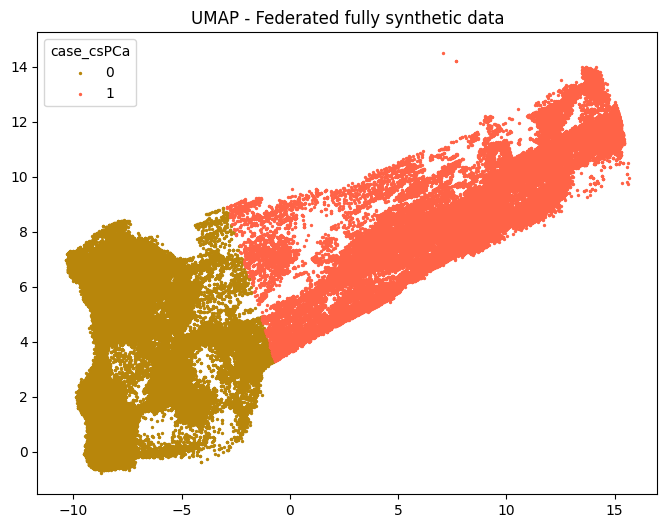


KS distance per feature:
  patient_age: 0.0861
  psa: 0.3031
  prostate_volume: 0.2014
Mean KS distance: 0.1968

TSTR AUC:      0.7187
TSTR F1:       0.5950
TSTR Accuracy: 0.7489

Total federated fully synthetic samples: 281382

Per-hospital synthetic counts:
  Hospital 0: 91652 validated samples
  Hospital 1: 102826 validated samples
  Hospital 2: 86904 validated samples


In [13]:
# Visualize the final federated synthetic dataset
X_fully = fully_synth.drop(['case_csPCa'], axis=1)
y_fully = fully_synth['case_csPCa'].values.flatten()

# Project the synthetic data through the EXISTING anchor manifold (no refit)
X_fully_norm = federated_standardize(X_fully.to_numpy())
umap_fully = manifold.transform(X_fully_norm)

plt.figure(figsize=(8, 6))
class_0_idx = y_fully == 0.0
plt.scatter(umap_fully[class_0_idx, 0], umap_fully[class_0_idx, 1],
            c='darkgoldenrod', label='0', s=2)
class_1_idx = y_fully == 1.0
plt.scatter(umap_fully[class_1_idx, 0], umap_fully[class_1_idx, 1],
            c='tomato', label='1', s=2)
plt.legend(title='case_csPCa')
plt.title('UMAP - Federated fully synthetic data')
plt.savefig('B_fed_synth_combined.png', dpi=200, bbox_inches='tight')
plt.show()

# Fidelity (KS distance) and Utility (TSTR)
from scipy.stats import ks_2samp
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split

# Real centralized PI-CAI for comparison (with KNN imputation)
real_full = pd.read_csv('marksheet_minimal.csv').drop(['psad', 'psad_computed'], axis=1)
real_full = pd.DataFrame(KNNImputer(n_neighbors=10).fit_transform(real_full),
                          columns=real_full.columns)

# Fidelity: KS distance
ks_results = {}
for feature in FEATURES:
    stat, _ = ks_2samp(real_full[feature], fully_synth[feature])
    ks_results[feature] = stat

print('\nKS distance per feature:')
for f, v in ks_results.items():
    print(f'  {f}: {v:.4f}')
print(f'Mean KS distance: {sum(ks_results.values()) / len(ks_results):.4f}')

# Utility: TSTR with Random Forest
X_real = real_full.drop('case_csPCa', axis=1)
y_real = real_full['case_csPCa']
_, X_test_real, _, y_test_real = train_test_split(
    X_real, y_real, test_size=0.3, stratify=y_real, random_state=42
)

X_synth = fully_synth.drop('case_csPCa', axis=1)
y_synth = fully_synth['case_csPCa']

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_synth, y_synth)
y_pred = clf.predict(X_test_real)
y_proba = clf.predict_proba(X_test_real)[:, 1]

print()
print(f'TSTR AUC:      {roc_auc_score(y_test_real, y_proba):.4f}')
print(f'TSTR F1:       {f1_score(y_test_real, y_pred):.4f}')
print(f'TSTR Accuracy: {accuracy_score(y_test_real, y_pred):.4f}')
print(f'\nTotal federated fully synthetic samples: {len(fully_synth)}')

# Per-hospital counts
print('\nPer-hospital synthetic counts:')
for i, sub in enumerate(per_site_synth):
    print(f'  Hospital {i}: {len(sub)} validated samples')